In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv("C:/Users/Hebin/Desktop/Nest internship/python basics/Sport car price.csv")

# Check column names
print(df.columns)

# Clean Horsepower
df["Horsepower"] = (
    df["Horsepower"]
    .astype(str)
    .str.replace("+", "", regex=False)
)
df["Horsepower"] = pd.to_numeric(df["Horsepower"], errors="coerce")

# Clean Torque
df["Torque (lb-ft)"] = (
    df["Torque (lb-ft)"]
    .astype(str)
    .str.replace("+", "", regex=False)
)
df["Torque (lb-ft)"] = pd.to_numeric(df["Torque (lb-ft)"], errors="coerce")

# Clean Engine Size (use exact column name from your dataset)
df["Engine Size (L)"] = pd.to_numeric(
    df["Engine Size (L)"],
    errors="coerce"
)

# Clean Price
df["Price (in USD)"] = (
    df["Price (in USD)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df["Price (in USD)"] = pd.to_numeric(
    df["Price (in USD)"],
    errors="coerce"
)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Descriptive statistics
print("\nDescriptive Statistics:")
numeric_df.describe().T

Index(['Car Make', 'Car Model', 'Year', 'Engine Size (L)', 'Horsepower',
       'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)'],
      dtype='str')

Data Types:
Car Make                       str
Car Model                      str
Year                         int64
Engine Size (L)            float64
Horsepower                 float64
Torque (lb-ft)             float64
0-60 MPH Time (seconds)        str
Price (in USD)               int64
dtype: object

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Year,1007.0,2021.201589,2.019802,1965.0,2021.0,2021.0,2022.00,2023.0
Engine Size (L),948.0,4.395781,1.398801,0.0,3.5,4.0,5.20,8.4
Horsepower,1002.0,637.794411,421.533521,181.0,454.0,591.0,689.75,10000.0
Torque (lb-ft),999.0,542.185185,242.509345,0.0,406.0,509.0,604.00,1732.0
Price (in USD),1007.0,382035.941410,738322.716090,25000.0,71800.0,140000.0,250000.00,5200000.0


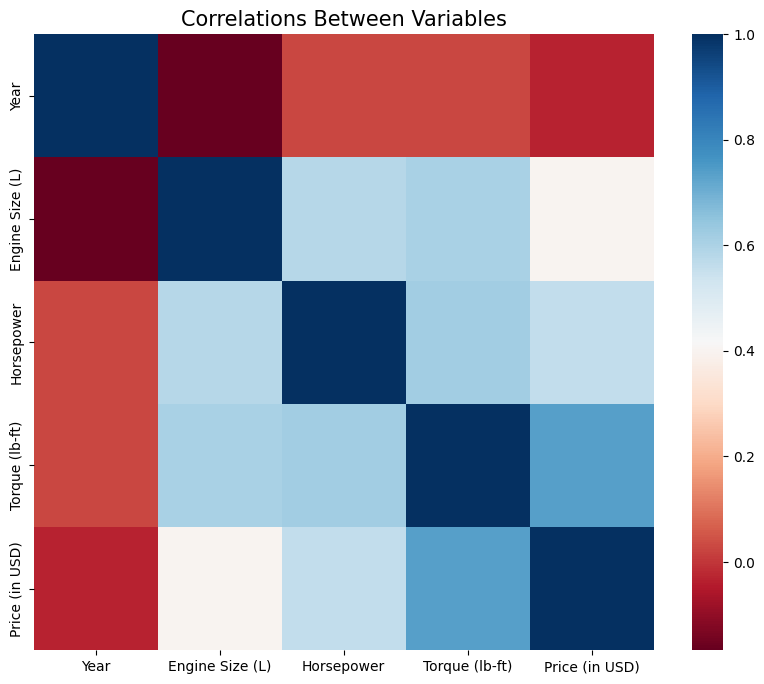

In [2]:

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(numeric_only=True), cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.show()

In [3]:
# Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Find important numeric features based on correlation with Price
important_num_cols = list(
    numeric_df.corr()['Price (in USD)'][
        abs(numeric_df.corr()['Price (in USD)']) > 0.50
    ].index
)

# Categorical columns
cat_cols = ['Car Make', 'Car Model']

# Combine important columns
important_cols = important_num_cols + cat_cols

# Create new dataframe with selected features
df = df[important_cols]

# Display selected columns
print("Selected Columns:")
print(df.columns)

# Preview data
df.head()

Selected Columns:
Index(['Horsepower', 'Torque (lb-ft)', 'Price (in USD)', 'Car Make',
       'Car Model'],
      dtype='str')


,Horsepower,Torque (lb-ft),Price (in USD),Car Make,Car Model
0,379.0,331.0,101200,Porsche,911
1,630.0,443.0,274390,Lamborghini,Huracan
2,661.0,561.0,333750,Ferrari,488 GTB
3,562.0,406.0,142700,Audi,R8
4,710.0,568.0,298000,McLaren,720S


In [4]:
# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Target variable
y = df['Price (in USD)']

# Features
X = df.drop('Price (in USD)', axis=1)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

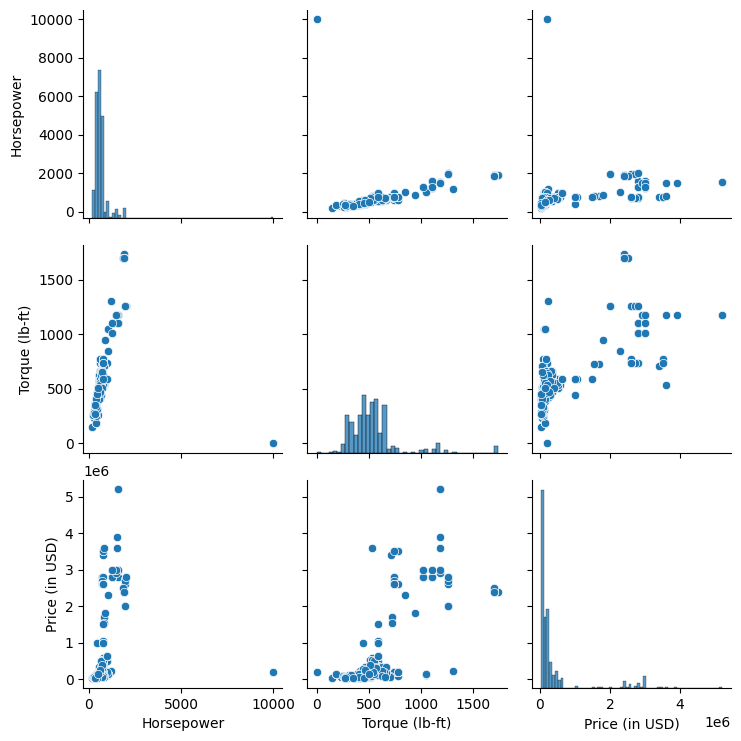

In [5]:
sns.pairplot(df[important_num_cols])

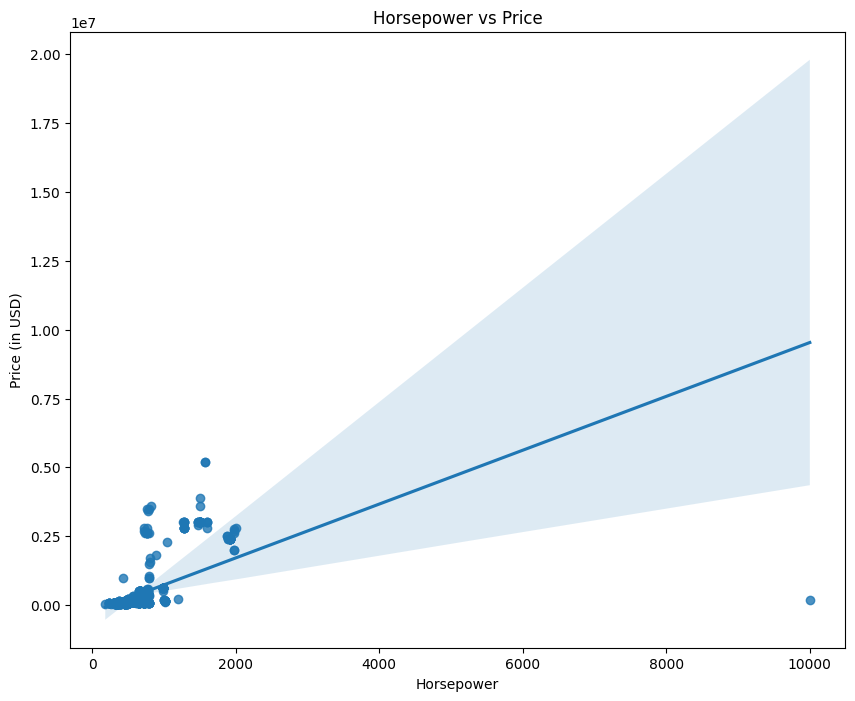

In [6]:
plt.figure(figsize=(10, 8))

sns.regplot(
    x=df["Horsepower"],
    y=df["Price (in USD)"]
)

plt.xlabel("Horsepower")
plt.ylabel("Price (in USD)")
plt.title("Horsepower vs Price")
plt.show()

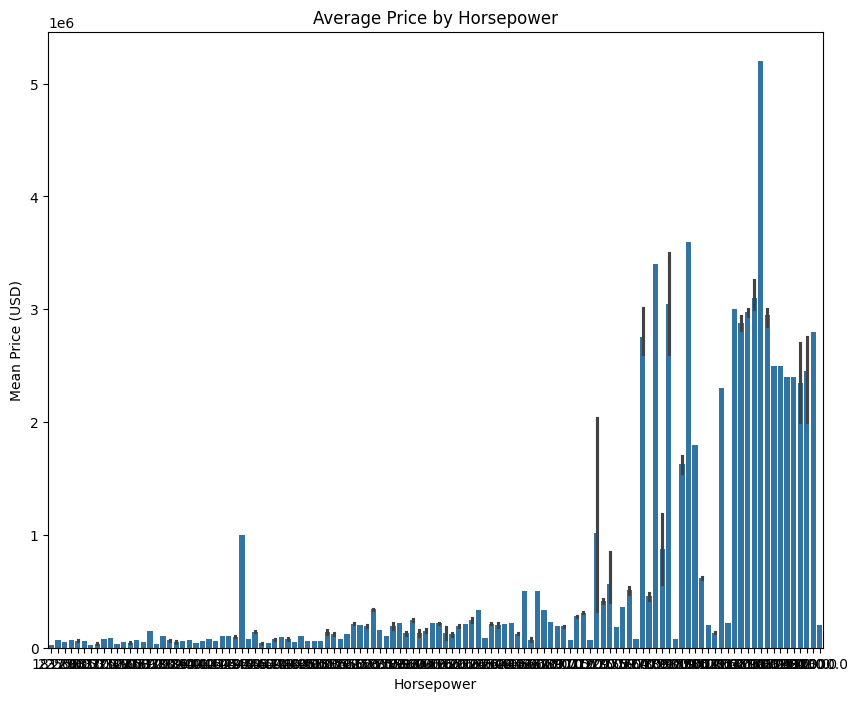

In [7]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=df["Horsepower"],
    y=df["Price (in USD)"]
)

plt.xlabel("Horsepower")
plt.ylabel("Mean Price (USD)")
plt.title("Average Price by Horsepower")
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

def rmse_cv(model):
    rmse = np.sqrt(
        -cross_val_score(
            model,
            X,
            y,
            scoring="neg_mean_squared_error",
            cv=5
        )
    ).mean()
    return rmse

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r_squared = r2_score(y, predictions)

    return mae, mse, rmse, r_squared

In [9]:
models = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score","RMSE (Cross-Validation)"])

In [10]:
print(df.isnull().sum())
print(X.dtypes)

Horsepower               5
Torque (lb-ft)           8
Price (in USD)           0
Car Make_Alfa Romeo      0
Car Make_Alpine          0
                        ..
Car Model_WRX STI        0
Car Model_Wraith         0
Car Model_Z4 M40i        0
Car Model_Z4 Roadster    0
Car Model_i8             0
Length: 215, dtype: int64
Horsepower               float64
Torque (lb-ft)           float64
Car Make_Alfa Romeo         bool
Car Make_Alpine             bool
Car Make_Ariel              bool
                          ...   
Car Model_WRX STI           bool
Car Model_Wraith            bool
Car Model_Z4 M40i           bool
Car Model_Z4 Roadster       bool
Car Model_i8                bool
Length: 214, dtype: object


In [11]:
X["Horsepower"] = X["Horsepower"].fillna(X["Horsepower"].median())
X["Torque (lb-ft)"] = X["Torque (lb-ft)"].fillna(X["Torque (lb-ft)"].median())

In [12]:
print(X.isnull().sum().sum())

0


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

l_reg = LinearRegression()
l_reg.fit(X_train, y_train)

predictions = l_reg.predict(X_test)

In [15]:
predictions

array([  78518.74999376,  214405.32146779,  311046.97929219,
        670138.06074944,  602490.51627219,   70697.77962961,
        311046.97929219,  326049.99999512,  205915.0312179 ,
        144161.37736623,  500005.58059057,   70200.54032545,
         84595.00000584,  196837.18750193,  145533.54503821,
        113999.99998865,   67150.00001069,   64627.00000233,
         46381.94444445, 1091949.91239357,   64413.26923264,
        618789.47368383,  423125.73177434,   75100.00001387,
         75040.46892995,  158044.09090854,   64627.00000233,
        611202.62753901,  334460.9825603 ,  158044.09090854,
        185000.00000252,  169144.15343816,  102274.99998862,
         46381.94444445,  327499.99998546,   71423.76532903,
       3002615.02316989,  196837.18750193,  219158.75665575,
       3046852.69492709,  129108.31276359, 2399167.30731971,
        211305.30592562,  311046.97929219,  102162.70833327,
        500005.58059057,  102162.70833327,  196837.18750193,
        157498.15454036,

In [16]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(l_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "LinearRegression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
new_row_df=pd.DataFrame([new_row])
model=pd.concat([models,new_row_df],ignore_index=True)

MAE: 47351.18876911038
MSE: 39449498313.018234
RMSE: 198618.97772624405
R2 Score: 0.9349731332002719
------------------------------
RMSE Cross-Validation: 179078.05199068837


In [17]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.5)  # You can adjust the alpha parameter
ridge_reg.fit(X_train, y_train)
predictions_ridge = ridge_reg.predict(X_test)

In [18]:
predictions_ridge

array([  90334.89999527,  261788.04385508,  315682.966578  ,
       1544904.06316071,  111404.95253614,   90442.47994606,
        315682.966578  ,  313431.25263034,  196303.55111086,
        137639.39018243,  475610.28649364,  -25340.60609245,
         84546.00794534,  198542.8636001 ,  332684.29561623,
        130048.56735408,   51059.35494596,   70213.12868578,
         46170.12370289, 1086360.04163361,   68935.87393565,
        613711.43102101,  441263.76970334,   69475.05979495,
         71966.02010984,  170429.82352561,   70213.12868578,
        295903.81357357,  385402.4440671 ,  170429.82352561,
        235980.62450899,  369310.3739529 ,   86577.47646124,
         46170.12370289,  319856.19590501,   53243.07711621,
       2110566.12814801,  198542.8636001 ,  241427.55597635,
       3048969.35057744,   87238.65178668, 2374454.08378284,
        239239.64836119,  315682.966578  ,  106806.23755203,
        475610.28649364,  106806.23755203,  198542.8636001 ,
        122595.27289473,

In [19]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_ridge)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(ridge_reg)
print("RMSE Cross-Validation:", rmse_cross_val)
new_row = {
    "Model": "Ridge Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)


MAE: 79224.88688456797
MSE: 58011988215.364975
RMSE: 240856.7794673112
R2 Score: 0.9043755182756512
------------------------------
RMSE Cross-Validation: 326066.64910858095


In [20]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.5)  # You can adjust the alpha parameter
lasso_reg.fit(X_train, y_train)
predictions_lasso = lasso_reg.predict(X_test)

In [21]:
predictions_lasso

array([  78565.92795651,  214592.71514155,  311007.0819294 ,
        428430.56798828,  355392.39839921,   70753.7003317 ,
        311007.0819294 ,  325642.71599511,  205827.15647215,
        144147.69243729,  499880.04123164,   69844.65956732,
         84458.75374998,  196857.61807184,  146244.22065293,
        113897.75942732,   67338.45287884,   64663.92030873,
         46354.95154828, 1546944.46533097,   64394.45882269,
        618767.76267406,  423175.57601152,   75500.84729501,
         75134.79240021,  158078.75938224,   64663.92030873,
        364799.16851556,  334703.92289944,  158078.75938224,
        184898.75707495,  129711.75022792,  102068.91642638,
         46354.95154828,  327295.60980493,   71316.22193824,
       2999116.21985157,  196857.61807184,  219188.49493931,
       3046875.57160335,   70627.79170169, 2399090.26337757,
        211416.37601307,  311007.0819294 ,  102176.64017544,
        499880.04123164,  102176.64017544,  196857.61807184,
        117137.46100108,

In [22]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_lasso)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(lasso_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

import pandas as pd

new_row = {
    "Model": "Lasso Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 35300.480531520894
MSE: 24032438025.263577
RMSE: 155023.9917730916
R2 Score: 0.9603859563956525
------------------------------
RMSE Cross-Validation: 154907.9598108373


In [23]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100)  # You can adjust the number of estimators
rf_reg.fit(X_train, y_train)
predictions_rf = rf_reg.predict(X_test)

In [24]:
predictions_rf 

array([  78467.02659563,  211841.57694552,  314103.25015873,
       2660877.93650794,   65958.62400794,  107042.05333333,
        314103.25015873,  325246.41777778,  193519.24566876,
        141827.40167272,  500000.        ,   64485.15539738,
         84500.05      ,  196884.97541493,  135922.23255051,
        114002.72727273,   66070.30416667,   64570.79038378,
         46371.31730506,  895772.09365079,   64430.09464167,
        618832.67863223,  427252.55078571,   75195.75      ,
         75112.5       ,  158018.90508176,   64570.79038378,
         61289.13863212,  331070.80239899,  158018.90508176,
        185050.        ,  173274.63558547,  102031.89182349,
         46371.31730506,  333915.12175926,   72253.54432276,
        193524.67644627,  196884.97541493,  219428.25984606,
       3071903.29396421,   74648.72270064, 2400000.        ,
        211238.05241454,  314103.25015873,  102162.0589769 ,
        500000.        ,  102162.0589769 ,  196884.97541493,
         71080.33048341,

In [25]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_rf)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(rf_reg)
print("RMSE Cross-Validation:", rmse_cross_val)
import pandas as pd

new_row = {
    "Model": "RandomForestRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 76052.14368238978
MSE: 130801683666.22072
RMSE: 361665.15406688093
R2 Score: 0.7843920955989272
------------------------------
RMSE Cross-Validation: 222495.8659165337


In [26]:
from sklearn.svm import SVR
svr_reg = SVR(kernel='rbf')  # You can choose different kernel functions (e.g., 'linear', 'poly', 'sigmoid')
svr_reg.fit(X_train, y_train)
predictions_svr = svr_reg.predict(X_test)

In [27]:
predictions_svr

array([134312.19853171, 134352.06100261, 134365.63720925, 134428.82562381,
       134273.23679191, 134363.19569722, 134365.63720925, 134359.50063813,
       134318.45149501, 134300.10000112, 134346.19326443, 134276.58730878,
       134300.56118211, 134320.65938917, 134423.64888754, 134339.33667604,
       134270.38368251, 134365.29017675, 134280.65759154, 134383.46586298,
       134354.39923981, 134396.80210549, 134353.13797657, 134303.71597901,
       134303.62820026, 134325.40742929, 134365.29017675, 134288.91135984,
       134349.59923842, 134325.40742929, 134380.52049152, 134348.53693671,
       134289.64197547, 134280.65759154, 134359.50062404, 134304.46764748,
       134331.35052264, 134320.65938917, 134350.76218734, 134433.25496461,
       134304.46767701, 134400.96462315, 134330.42867564, 134365.63720925,
       134290.39928218, 134346.19326443, 134290.39928218, 134320.65938917,
       134310.38110325, 134303.52775734, 134300.10000112, 134352.94680754,
       134286.32236557, 1

In [28]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_svr)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(svr_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 327277.8984348018
MSE: 680919498084.5438
RMSE: 825178.4643848528
R2 Score: -0.12239859559049826
------------------------------
RMSE Cross-Validation: 771552.2584976392


In [29]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
gb_reg = GradientBoostingRegressor(n_estimators=100)  # You can adjust the number of estimators
gb_reg.fit(X_train, y_train)
predictions_gb = gb_reg.predict(X_test)

In [30]:
predictions_gb

array([ 111938.80232554,  202779.19574974,  290537.75632358,
       2842914.66342248,   68420.1986553 ,   90546.53362452,
        290537.75632358,  353191.01411176,  124796.63753912,
        113137.68256966,  448623.36161038,   70610.34106042,
         90438.40195526,  162237.39286137,  179202.06147646,
        145855.57052061,   68420.1986553 ,   90546.53362452,
         66157.8413002 , 1348279.75043883,   89879.51316386,
        614635.43349641,  397175.02800381,   89976.15245898,
         89976.15245898,  155232.42628636,   90546.53362452,
         73049.42464801,  295622.53977351,  155232.42628636,
        248355.1288387 ,  166582.11808607,   96392.21328027,
         66157.8413002 ,  353191.01411176,   90438.40195526,
        200516.90027739,  162237.39286137,  209599.71320541,
       3036982.19732543,   90438.40195526, 2405540.37438194,
        235107.66811076,  290537.75632358,   96392.21328027,
        448623.36161038,   96392.21328027,  162237.39286137,
         96392.21328027,

In [31]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_gb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(gb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)
new_row = {
    "Model": "GradientBoostingRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 89655.44147131544
MSE: 125004273203.44775
RMSE: 353559.4337638974
R2 Score: 0.7939482992027049
------------------------------
RMSE Cross-Validation: 205880.61980119097


In [32]:
xgb_reg = XGBRegressor(n_estimators=100)  # You can adjust the number of estimators
xgb_reg.fit(X_train, y_train)
predictions_xgb = xgb_reg.predict(X_test)

In [33]:
predictions_xgb

array([8.12672109e+04, 2.14166203e+05, 3.08908000e+05, 2.87819350e+06,
       7.11860391e+04, 1.17872234e+05, 3.08908000e+05, 3.17427031e+05,
       1.85064547e+05, 1.40402984e+05, 4.96248094e+05, 6.12263906e+04,
       8.23771406e+04, 1.95141625e+05, 1.33489031e+05, 1.15639609e+05,
       6.60264531e+04, 6.57089141e+04, 4.61550547e+04, 1.53603688e+06,
       6.50280039e+04, 6.16744688e+05, 4.29523562e+05, 7.60984219e+04,
       7.60984219e+04, 1.58837000e+05, 6.57089141e+04, 6.97593125e+04,
       3.13990031e+05, 1.58837000e+05, 1.80525281e+05, 1.57409891e+05,
       9.73175234e+04, 4.61550547e+04, 3.25328719e+05, 7.30140703e+04,
       1.92818984e+05, 1.95141625e+05, 2.17965719e+05, 3.07618025e+06,
       7.51222031e+04, 2.40143300e+06, 2.14608203e+05, 3.08908000e+05,
       1.01352648e+05, 4.96248094e+05, 1.01352648e+05, 1.95141625e+05,
       7.60151172e+04, 9.20960391e+04, 1.40402984e+05, 4.35312719e+05,
       5.98160898e+04, 9.91475312e+05, 1.95141625e+05, 6.57089141e+04,
      

In [34]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_xgb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(xgb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {
    "Model": "XGBRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)


MAE: 70703.6796875
MSE: 132444094464.0
RMSE: 363928.6942025869
R2 Score: 0.7816848158836365
------------------------------
RMSE Cross-Validation: 192339.469202151


In [35]:
import lightgbm as lgb
lgb_reg = lgb.LGBMRegressor(n_estimators=100)  # You can adjust the number of estimators
lgb_reg.fit(X_train, y_train)
predictions_lgb = lgb_reg.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 181
[LightGBM] [Info] Number of data points in the train set: 805, number of used features: 25
[LightGBM] [Info] Start training from score 375796.752795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [36]:
predictions_lgb

array([  85380.2324508 ,  188429.61010881,  317897.02927063,
       2888180.43262233,   66703.78716424,  -11297.02683879,
        317897.02927063,  561041.29827121,  166577.21228229,
        141391.1107468 ,  506852.16854317,   58886.73618163,
         81782.80529023,  197322.42601004,  389102.04619578,
        113259.64404804,   66703.78716424,   62340.24941962,
         46093.72294031, 1858642.08216763,   63955.11967681,
        621426.82067011,  446053.36263678,  102411.08259317,
        102411.08259317,  158634.6014832 ,   62340.24941962,
         77969.63862981,  249326.56725533,  158634.6014832 ,
        707179.52070479,  131732.58307668,  103591.88344676,
         46093.72294031,  561041.29827121,   71728.1896118 ,
        191584.03756608,  197322.42601004,  218558.0402165 ,
       3041916.32362828,   71728.1896118 , 2575942.0254897 ,
        212536.32484977,  317897.02927063,  105921.1408393 ,
        506852.16854317,  105921.1408393 ,  197322.42601004,
         68647.14451634,

In [37]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_lgb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(lgb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)
new_row = {
    "Model": "LGBMRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 114945.92376411942
MSE: 181238419868.61688
RMSE: 425721.0587563374
R2 Score: 0.7012543354980862
------------------------------
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000164 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 182
[LightGBM] [Info] Number of data points in the train set: 805, number of used features: 26
[LightGBM] [Info] Start training from score 386824.663354
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [38]:
models.sort_values(by="RMSE (Cross-Validation)")

,Model,MAE,MSE,RMSE,R2 Score,RMSE (Cross-Validation)
1,Lasso Regression,35300.480532,24032438025.263577,155023.991773,0.960386,154907.959811
5,XGBRegressor,70703.679688,132444094464.0,363928.694203,0.781685,192339.469202
4,GradientBoostingRegressor,89655.441471,125004273203.447754,353559.433764,0.793948,205880.619801
2,RandomForestRegressor,76052.143682,130801683666.220718,361665.154067,0.784392,222495.865917
3,RandomForestRegressor,76052.143682,130801683666.220718,361665.154067,0.784392,222495.865917
6,LGBMRegressor,114945.923764,181238419868.616882,425721.058756,0.701254,261965.162187
0,Ridge Regression,79224.886885,58011988215.364975,240856.779467,0.904376,326066.649109


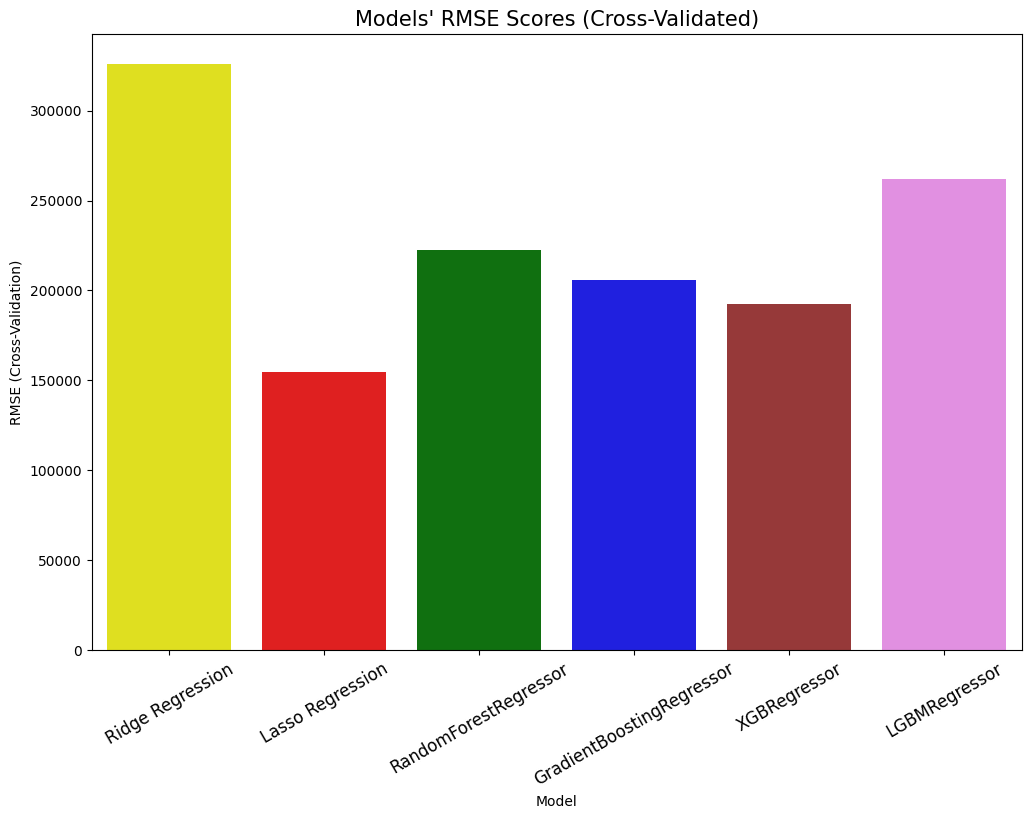

In [39]:
plt.figure(figsize=(12,8))
color=["yellow","red","green","blue","brown","violet"]
sns.barplot(x=models["Model"], y=models["RMSE (Cross-Validation)"],palette=color)
plt.title("Models' RMSE Scores (Cross-Validated)", size=15)
plt.xticks(rotation=30, size=12)
plt.show()

In [40]:
gb_reg.fit(X_train, y_train)

predictions = gb_reg.predict(X_test)

mae, mse, rmse, r_squared = evaluation(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(gb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)
new_row = {
    "Model": "GradientBoostingRegressor - Selected",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 89753.10652910215
MSE: 125969262119.71552
RMSE: 354921.48726121883
R2 Score: 0.7923576527203731
------------------------------
RMSE Cross-Validation: 208611.96506599768


In [41]:
import joblib

# Save the best model
joblib.dump(lasso_reg, "best_model.pkl")

print("Best model saved successfully as best_model.pkl")

Best model saved successfully as best_model.pkl


In [42]:
import joblib

model_data = {
    "model": lasso_reg,
    "columns": X_train.columns.tolist()
}

joblib.dump(model_data, "sport_car_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [47]:
import pandas as pd
import joblib

saved_model = joblib.load("sport_car_price_model.pkl")

model = saved_model["model"]
columns = saved_model["columns"]

# Create input
new_data = pd.DataFrame(0, index=[0], columns=columns)

new_data["Horsepower"] = 500
new_data["Torque (lb-ft)"] = 450
new_data["Car Make_BMW"] = 1
new_data["Car Model_M4"] = 1

prediction = model.predict(new_data)

print(prediction)

[74282.08433062]
